In [2]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
bird = pd.read_csv("../data/df_all_bird.csv")

/var/folders/h0/khxnf7v151599zc19wcwyyfw0000gn/T/ipykernel_2055/336179279.py:4: DtypeWarning: Columns (0: RISERVATO) have mixed types. Specify dtype option on import or set low_memory=False.
  bird = pd.read_csv("../data/df_all_bird.csv")


In [3]:
bird = bird.rename(columns={
    "LATITUDINE_INIZIO_CORSA": "start_lat",
    "LONGITUTIDE_INIZIO_CORSA": "start_lon",
    "LATITUDINE_FINE_CORSA": "end_lat",
    "LONGITUTIDE_FINE_CORSA": "end_lon",
    "DATAORA_INIZIO": "start_time",
    "DATAORA_FINE": "end_time"
})


In [4]:
bird["start_time"] = pd.to_datetime(bird["start_time"])
bird["end_time"]   = pd.to_datetime(bird["end_time"])


In [5]:
print("\nbird columns:\n", bird.columns)


bird columns:
 Index(['ID_VEICOLO', 'start_time', 'end_time', 'start_lat', 'start_lon',
       'end_lat', 'end_lon', 'PERCORSO', 'DISTANZA_KM', 'DURATA_MIN',
       'RISERVATO', 'DURATA_H', 'SPEED_KMH', 'HAV_DIST_KM', 'date', 'hour',
       'year'],
      dtype='str')


In [6]:
bird = bird.sort_values(by=['ID_VEICOLO', 'start_time'])

In [7]:
bird[['ID_VEICOLO', 'start_time', 'end_time']].head(20)

,ID_VEICOLO,start_time,end_time
1947,11CAM,2024-01-04 15:57:00,2024-01-04 16:09:00
3877,11CAM,2024-01-08 16:23:00,2024-01-08 16:31:00
4220,11CAM,2024-01-09 12:28:00,2024-01-09 12:31:00
4221,11CAM,2024-01-09 12:37:00,2024-01-09 12:44:00
5459,11CAM,2024-01-11 14:38:00,2024-01-11 14:41:00
5529,11CAM,2024-01-11 15:59:00,2024-01-11 16:04:00
5611,11CAM,2024-01-11 17:32:00,2024-01-11 17:55:00
5677,11CAM,2024-01-11 18:48:00,2024-01-11 18:57:00
5726,11CAM,2024-01-11 19:45:00,2024-01-11 19:53:00
5757,11CAM,2024-01-11 20:38:00,2024-01-11 20:41:00


In [8]:
bird.sort_values(by='start_time').head(20)

,ID_VEICOLO,start_time,end_time,start_lat,start_lon,end_lat,end_lon,PERCORSO,DISTANZA_KM,DURATA_MIN,RISERVATO,DURATA_H,SPEED_KMH,HAV_DIST_KM,date,hour,year
1,XN4B6,2024-01-01 01:00:00,2024-01-01 01:03:00,45.052023,7.674939,45.052862,7.679611,NaN,0.50,3.08,NaN,0.051333,9.740260,0.378660,2024-01-01 01:00:00,1,2024
0,8AD7P,2024-01-01 01:00:00,2024-01-01 01:22:00,45.071664,7.695770,45.058830,7.678815,NaN,3.20,22.05,NaN,0.367500,8.707483,1.951903,2024-01-01 01:00:00,1,2024
3,BD8V5,2024-01-01 01:02:00,2024-01-01 01:14:00,45.066468,7.681988,45.056301,7.673063,NaN,1.50,11.92,NaN,0.198667,7.550336,1.330182,2024-01-01 01:02:00,1,2024
2,JQ2JD,2024-01-01 01:02:00,2024-01-01 01:29:00,45.066525,7.682050,45.055685,7.672043,NaN,1.80,27.20,NaN,0.453333,3.970588,1.438974,2024-01-01 01:02:00,1,2024
4,2YBLH,2024-01-01 01:03:00,2024-01-01 01:22:00,45.061798,7.680334,45.064752,7.694430,NaN,2.71,18.35,NaN,0.305833,8.861035,1.154845,2024-01-01 01:03:00,1,2024
5,M4U7F,2024-01-01 01:03:00,2024-01-01 01:25:00,45.067973,7.653898,45.067377,7.689762,NaN,4.31,22.20,NaN,0.370000,11.648649,2.817253,2024-01-01 01:03:00,1,2024
6,APS9L,2024-01-01 01:04:00,2024-01-01 01:09:00,45.068075,7.690302,45.060608,7.684984,NaN,1.30,4.83,NaN,0.080500,16.149068,0.929430,2024-01-01 01:04:00,1,2024
7,AM3JL,2024-01-01 01:04:00,2024-01-01 01:19:00,45.063487,7.655343,45.046928,7.640894,NaN,3.03,14.58,NaN,0.243000,12.469136,2.162915,2024-01-01 01:04:00,1,2024
10,REEJ3,2024-01-01 01:05:00,2024-01-01 01:25:00,45.095511,7.672255,45.066446,7.692833,NaN,6.50,19.92,NaN,0.332000,19.578313,3.613216,2024-01-01 01:05:00,1,2024
8,7CK52,2024-01-01 01:05:00,2024-01-01 01:17:00,45.056423,7.641999,45.035852,7.644580,NaN,3.70,12.27,NaN,0.204500,18.092910,2.296326,2024-01-01 01:05:00,1,2024


In [9]:
bird['next_start_time'] = bird.groupby('ID_VEICOLO')['start_time'].shift(-1)

bird['parking_duration'] = bird['next_start_time'] - bird['end_time']

In [10]:
bird['parking_minutes'] = bird['parking_duration'].dt.total_seconds() / 60

In [11]:
bird[['ID_VEICOLO', 'end_time', 'next_start_time', 'parking_minutes']].head(20)

,ID_VEICOLO,end_time,next_start_time,parking_minutes
1947,11CAM,2024-01-04 16:09:00,2024-01-08 16:23:00,5774.0
3877,11CAM,2024-01-08 16:31:00,2024-01-09 12:28:00,1197.0
4220,11CAM,2024-01-09 12:31:00,2024-01-09 12:37:00,6.0
4221,11CAM,2024-01-09 12:44:00,2024-01-11 14:38:00,2994.0
5459,11CAM,2024-01-11 14:41:00,2024-01-11 15:59:00,78.0
5529,11CAM,2024-01-11 16:04:00,2024-01-11 17:32:00,88.0
5611,11CAM,2024-01-11 17:55:00,2024-01-11 18:48:00,53.0
5677,11CAM,2024-01-11 18:57:00,2024-01-11 19:45:00,48.0
5726,11CAM,2024-01-11 19:53:00,2024-01-11 20:38:00,45.0
5757,11CAM,2024-01-11 20:41:00,2024-01-12 13:05:00,984.0


In [12]:
voi_clean = bird[
    (bird['parking_minutes'] > 0) & 
    (bird['parking_minutes'] < 10000)
]

In [13]:
from shapely.geometry import Point

bird['geometry'] = bird.apply(
    lambda row: Point(float(row['end_lon']), float(row['end_lat'])),
    axis=1
)

bird_gdf = gpd.GeoDataFrame(bird, geometry='geometry', crs='EPSG:4326')

In [14]:
zones = gpd.read_file("/Users/mina/Desktop/EX4/Turin_Zone.gpkg")

In [15]:
zones = zones.to_crs(bird_gdf.crs)

In [16]:
bird_zones = gpd.sjoin(bird_gdf, zones, how='left', predicate='within')

In [17]:
bird_zones.head()

,ID_VEICOLO,start_time,end_time,start_lat,start_lon,end_lat,end_lon,PERCORSO,DISTANZA_KM,DURATA_MIN,...,date,hour,year,next_start_time,parking_duration,parking_minutes,geometry,index_right,ZONASTAT,DENOM
1947,11CAM,2024-01-04 15:57:00,2024-01-04 16:09:00,45.071030,7.665938,45.081808,7.642635,NaN,3.30,11.40,...,2024-01-04 15:57:00,15,2024,2024-01-08 16:23:00,4 days 00:14:00,5774.0,POINT (7.64263 45.08181),43.0,30,La Tesoriera - Martinetto
3877,11CAM,2024-01-08 16:23:00,2024-01-08 16:31:00,45.081821,7.642798,45.070784,7.661885,NaN,2.80,8.72,...,2024-01-08 16:23:00,16,2024,2024-01-09 12:28:00,0 days 19:57:00,1197.0,POINT (7.66189 45.07078),32.0,17,Mercato del Bestiame - Aiuola Martini
4220,11CAM,2024-01-09 12:28:00,2024-01-09 12:31:00,45.070645,7.661113,45.076126,7.662702,NaN,0.99,3.25,...,2024-01-09 12:28:00,12,2024,2024-01-09 12:37:00,0 days 00:06:00,6.0,POINT (7.6627 45.07613),32.0,17,Mercato del Bestiame - Aiuola Martini
4221,11CAM,2024-01-09 12:37:00,2024-01-09 12:44:00,45.076320,7.662661,45.063905,7.651992,NaN,2.30,6.97,...,2024-01-09 12:37:00,12,2024,2024-01-11 14:38:00,2 days 01:54:00,2994.0,POINT (7.65199 45.0639),45.0,33,Borgo San Paolo
5459,11CAM,2024-01-11 14:38:00,2024-01-11 14:41:00,45.063882,7.651982,45.060584,7.646131,NaN,0.80,2.48,...,2024-01-11 14:38:00,14,2024,2024-01-11 15:59:00,0 days 01:18:00,78.0,POINT (7.64613 45.06058),48.0,35,Polo Nord


In [18]:
bird_zones.columns

Index(['ID_VEICOLO', 'start_time', 'end_time', 'start_lat', 'start_lon',
       'end_lat', 'end_lon', 'PERCORSO', 'DISTANZA_KM', 'DURATA_MIN',
       'RISERVATO', 'DURATA_H', 'SPEED_KMH', 'HAV_DIST_KM', 'date', 'hour',
       'year', 'next_start_time', 'parking_duration', 'parking_minutes',
       'geometry', 'index_right', 'ZONASTAT', 'DENOM'],
      dtype='str')

In [19]:
avg_parking = bird_zones.groupby('ZONASTAT')['parking_minutes'].mean().reset_index()

In [20]:
avg_parking.head()

,ZONASTAT,parking_minutes
0,01,1010.196149
1,02,1031.822231
2,03,865.055859
3,04,1028.874869
4,05,1254.194155


In [21]:
zones_avg = zones.merge(avg_parking, on='ZONASTAT', how='left')

In [22]:
zones_avg[['ZONASTAT', 'parking_minutes']].head()

,ZONASTAT,parking_minutes
0,70,1741.640328
1,42,1104.896534
2,55,905.907789
3,06,711.795906
4,09,958.667074


In [23]:
pip install matplotlib


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [24]:
import matplotlib.pyplot as plt

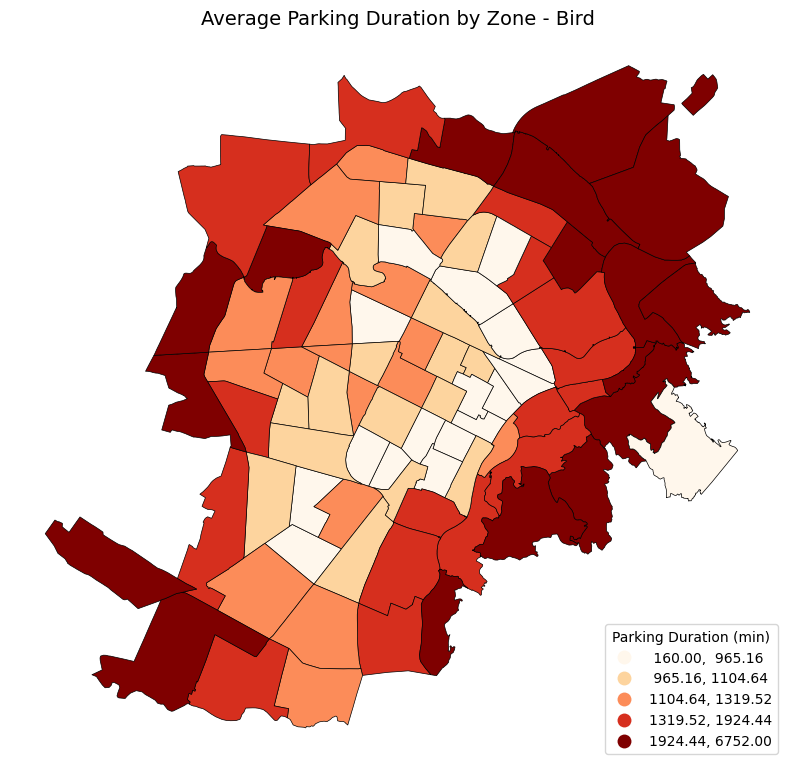

In [25]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(10,10))

zones_avg.plot(
    column='parking_minutes',
    cmap='OrRd',
    scheme='quantiles',   # تقسیم به کلاس
    k=5,                  # تعداد کلاس‌ها
    linewidth=0.5,
    edgecolor='black',
    legend=True,
    legend_kwds={
        'title': 'Parking Duration (min)',
        'loc': 'lower right'
    },
    ax=ax
)

ax.set_title('Average Parking Duration by Zone - Bird', fontsize=14)
ax.axis('off')

plt.show()

In [26]:
zones.total_bounds

array([ 7.57786722, 45.006773  ,  7.77338483, 45.14018759])

In [27]:
import folium

# ساخت نقشه پایه (مرکز تورین)
m = folium.Map(location=[45.07, 7.68], zoom_start=12)

# اضافه کردن choropleth
folium.Choropleth(
    geo_data=zones_avg,
    data=zones_avg,
    columns=['ZONASTAT', 'parking_minutes'],
    key_on='feature.properties.ZONASTAT',
    fill_color='OrRd',
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name='Average Parking Duration (minutes)'
).add_to(m)

m

In [28]:
zones_avg.to_file("bird_parking.geojson", driver="GeoJSON")